In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path 
import pickle
from src.feature_generation import pool_features
import numpy as np

encoder_name = "perch2"
dir = Path("/idiap/temp/adeych/data")
X_bags_dir = "perch2-bags.pkl"
with open(dir / "feature_banks" / X_bags_dir, "rb") as f:
    X_bags = pickle.load(f)
X_bags_pooled = pool_features(X_bags, windows=False,window_pooled=False,encoder = encoder_name)
y = np.load(dir / "feature_banks" / "labels.npy")

/idiap/temp/adeych/conda/envs/temp-env-4/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

class_names = ['type a', 'type b', 'type c', 'type d', 'echo']
embeddings = X_bags_pooled
labels = y
# 1. Flatten embeddings into (total_windows, dimension)
flat_embeddings = np.vstack(embeddings)

# 2. Tile the 5-element binary label vector across all windows of each audio clip
window_binary_labels = np.vstack([
    np.tile(item_label, (arr.shape[0], 1))
    for arr, item_label in zip(embeddings, labels)
])  # Shape: (total_windows, 5)

# 3. Fit t-SNE
tsne = TSNE(n_components=2, perplexity=30, metric='cosine', init='pca', random_state=42)
coords_2d = tsne.fit_transform(flat_embeddings)

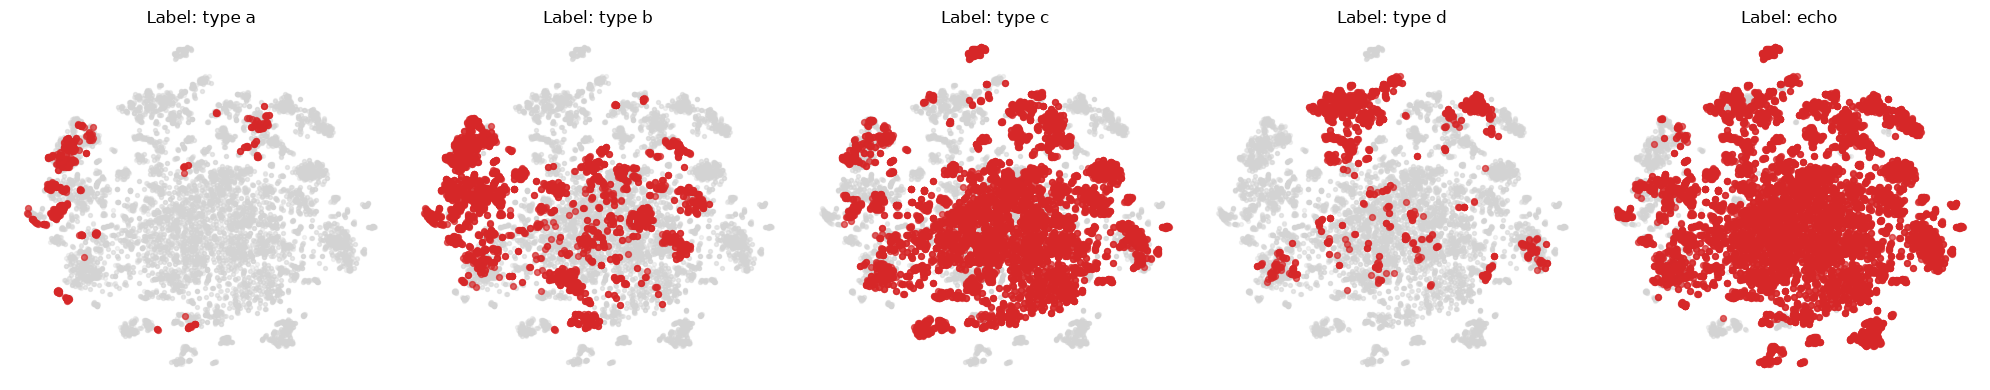

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)

for i, class_name in enumerate(class_names):
    has_label = window_binary_labels[:, i] == 1
    
    # Non-matching background windows
    axes[i].scatter(coords_2d[~has_label, 0], coords_2d[~has_label, 1], c='lightgrey', s=8, alpha=0.3)
    # Highlighted matching windows
    axes[i].scatter(coords_2d[has_label, 0], coords_2d[has_label, 1], c='tab:red', s=18, alpha=0.7)
    
    axes[i].set_title(f"Label: {class_name}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

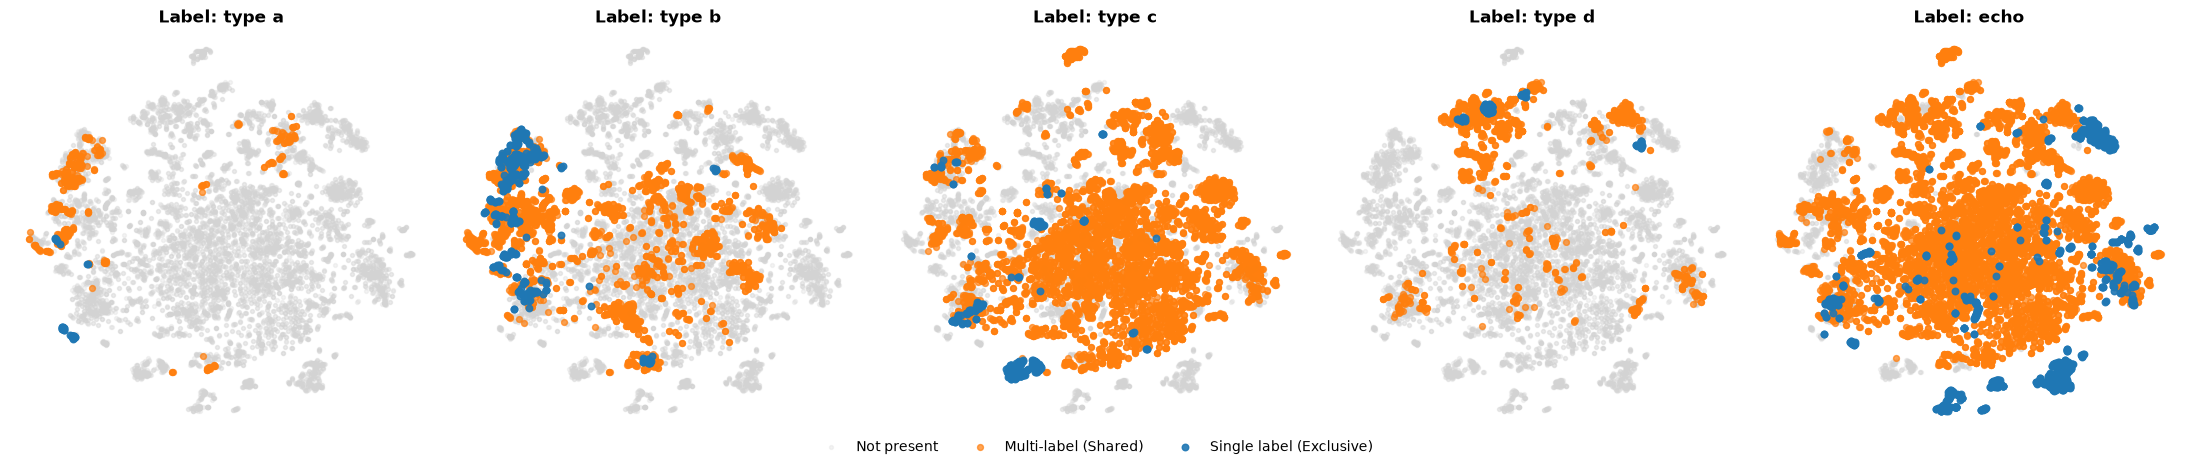

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Count how many labels are active for each window
label_counts = window_binary_labels.sum(axis=1)  # Shape: (total_windows,)

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharex=True, sharey=True)

for i, class_name in enumerate(class_names):
    has_label = (window_binary_labels[:, i] == 1)
    
    # 3 Distinct masks
    exclusive_label = has_label & (label_counts == 1)  # ONLY this label active
    co_occurring = has_label & (label_counts > 1)      # Active along with other labels
    no_label = ~has_label                              # Label not present

    # 1. Background (No label)
    axes[i].scatter(
        coords_2d[no_label, 0], coords_2d[no_label, 1], 
        c='lightgrey', s=8, alpha=0.25, label='Not present'
    )
    
    # 2. Co-occurring / Multi-label (e.g. Orange)
    axes[i].scatter(
        coords_2d[co_occurring, 0], coords_2d[co_occurring, 1], 
        c='tab:orange', s=18, alpha=0.7, label='Multi-label (Shared)'
    )
    
    # 3. Exclusive / Single label (e.g. Blue)
    axes[i].scatter(
        coords_2d[exclusive_label, 0], coords_2d[exclusive_label, 1], 
        c='tab:blue', s=22, alpha=0.9, label='Single label (Exclusive)'
    )
    
    axes[i].set_title(f"Label: {class_name}", fontsize=12, fontweight='bold')
    axes[i].axis('off')

# Single legend for the entire subplot figure
handles, labels_fig = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_fig, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.tight_layout()
plt.show()